____

## Naive  Bayes

____




### Description: 
#### Naive Bayes algorithm is a supervised learning algorithm, which is based on Bayes theorem and used for solving classification problems. It is mainly used in text classification that includes a high-dimensional training dataset. It is a probabilistic classifier, which means it predicts on the basis of the probability of an object.

____

### Algorith, : 

Step 1: Calculate the prior
probability for given class labels


Step 2: Find Likelihood
probability with each attribute for each class


Step 3: Put these value in
Bayes Formula and calculate posterior probability.


Step 4: Check which class has
a higher probability, given the input belongs to the higher probability class.



___
#### Dataset - Use Wine data from UCI


https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv
_____

## Step 0 : Import necessary libraries


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

## Step 1 : Load the data set

In [29]:
# file_path = r'E:\Z_Arise\ML_Lab\Ex_5_Naive_Bayes\wine.data'

# data = pd.read_csv(file_path)
# data.head()

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')
print(df.head())


   fixed acidity  volatile acidity  citric acid  ...  sulphates  alcohol  quality
0            7.4              0.70         0.00  ...       0.56      9.4        5
1            7.8              0.88         0.00  ...       0.68      9.8        5
2            7.8              0.76         0.04  ...       0.65      9.8        5
3           11.2              0.28         0.56  ...       0.58      9.8        6
4            7.4              0.70         0.00  ...       0.56      9.4        5

[5 rows x 12 columns]


In [30]:
print(" Shape of the Dataset : ", df.shape)
print(" name of the Features : ", df.columns)

 Shape of the Dataset :  (1599, 12)
 name of the Features :  Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [32]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Step - 2 : Prpeare the Data - Create Binary Classes



Original quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Binary class distribution:
quality_binary
Good    855
Bad     744
Name: count, dtype: int64

Numeric class distribution:
quality_numeric
1    855
0    744
Name: count, dtype: int64


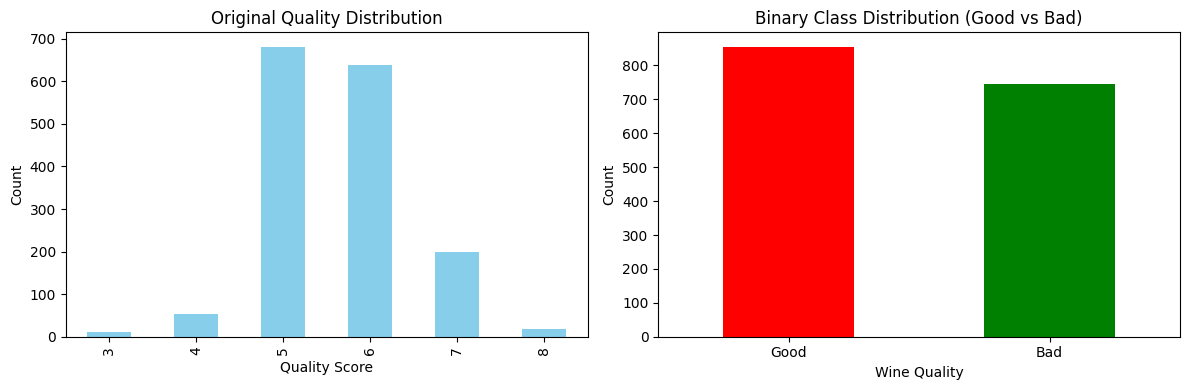

In [33]:
# Convert quality to binary classification (Good/Bad)
# Following your dataset, quality ranges from 3-8
# Let's define: Bad Wine = quality 3-5, Good Wine = quality 6-8

print("Original quality distribution:")
print(df['quality'].value_counts().sort_index())

# Create A binary Target
df['quality_binary'] = df['quality'].apply(lambda x : 'Good' if x>=6 else 'Bad')

# Alternate binary rep 0/1 for numeric rep
df['quality_numeric'] = df['quality'].apply(lambda x : 1 if x>=6 else 0)

print("\nBinary class distribution:")
print(df['quality_binary'].value_counts())
print("\nNumeric class distribution:")
print(df['quality_numeric'].value_counts())

#Visualize the distribution

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
df['quality'].value_counts().sort_index().plot(kind='bar',color='skyblue')
plt.title('Original Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['quality_binary'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Binary Class Distribution (Good vs Bad)')
plt.xlabel('Wine Quality')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Why we do this:

- Naive Bayes is a classification algorithm, so we need discrete classes

- Converting to binary simplifies the problem and matches the algorithm's requirements

- We can now calculate probabilities for 2 classes instead of 6

## Step 3 : Split the feature and the Target

In [34]:
# Separate features and target
X = df.drop(['quality', 'quality_binary', 'quality_numeric'], axis=1)  # Features
y = df['quality_numeric']  # Target (0=Bad, 1=Good)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature names:", list(X.columns))

Features shape: (1599, 11)
Target shape: (1599,)

Feature names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [35]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


## Step 3: Split Data into Training and Testing Sets

Why You Need It
- **Prevents Bias** : Without it, a random split might accidentally put all examples of a rare class into the test set, leaving the model with nothing to learn from in the training set.
- **Handles Imbalanced Data**: It is essential for datasets where one class is much smaller than another (e.g., fraud detection or rare disease diagnosis) to ensure the minority class is represented in both splits.
- **Reliable Evaluation**: Since the test set reflects the real-world distribution of your classes, your performance metrics (like accuracy or F1-score) become more trustworthy. 

#### When you set **stratify=y**, the train_test_split function from scikit-learn treats the values in y as "strata" (groups) and samples from each group proportionally.

In [36]:
# Split the data using train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify=y)


print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

Training set size: 1279 samples
Testing set size: 320 samples

Training set class distribution:
quality_numeric
1    684
0    595
Name: count, dtype: int64

Testing set class distribution:
quality_numeric
1    171
0    149
Name: count, dtype: int64


Why we do this:

- We need separate data for training (learning probabilities) and testing (evaluating performance)

- stratify=y ensures same class distribution in both sets

## Step 5 :  Scale the Features

In [37]:
# Scale features for better numerical stability
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

# Convert them back to DataFrame for easier viewing
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Original Training Data (first 5 rows):")
print(X_train.head())
print("\nScaled Training Data (first 5 rows):")
print(X_train_scaled_df.head())

Original Training Data (first 5 rows):
      fixed acidity  volatile acidity  citric acid  ...    pH  sulphates  alcohol
745             7.3              0.51         0.18  ...  3.52       0.73     9.50
823             6.7              0.54         0.13  ...  3.61       0.64     9.80
983             9.1              0.50         0.30  ...  3.32       0.71    10.50
1505            6.7              0.76         0.02  ...  3.55       0.63     9.95
1399            7.2              0.67         0.00  ...  3.42       0.72    11.10

[5 rows x 11 columns]

Scaled Training Data (first 5 rows):
   fixed acidity  volatile acidity  citric acid  ...        pH  sulphates   alcohol
0      -0.590966         -0.088985    -0.479265  ...  1.350662   0.432631 -0.874168
1      -0.932515          0.078962    -0.737340  ...  1.935417  -0.111633 -0.594279
2       0.433678         -0.144968     0.140115  ...  0.051206   0.311684  0.058793
3      -0.932515          1.310575    -1.305106  ...  1.545580  -0.17210

Why we do this:

- Gaussian Naive Bayes assumes features follow normal distribution

- Scaling helps normalize the data and improves probability calculations

# Main Algorith Implementation

## Step 6 : Calculate the Prior  Probability ( step 1 alg )



In [45]:
y 

0       0
1       0
2       0
3       1
4       0
       ..
1594    0
1595    1
1596    1
1597    0
1598    1
Name: quality_numeric, Length: 1599, dtype: int64

# From here take 1 - Good and 0 - Bad 

=== STEP 1: Prior Probabilities ===
Total training samples: 1279
Good wines (Class 1): 684
Bad wines (Class 0): 595

P(Good) = 684/1279 = 0.5348
P(Bad) = 595/1279 = 0.4652


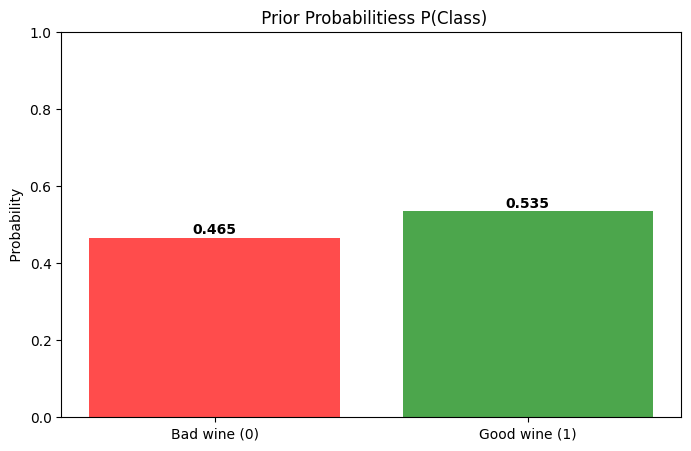

In [46]:
# calculate prior probabilities
n_samples = len(y_train)
n_good = sum(y_train == 1)
n_bad = sum(y_train == 0)

prior_good = n_good / n_samples
prior_bad = n_bad / n_samples

print("=== STEP 1: Prior Probabilities ===")
print(f"Total training samples: {n_samples}")
print(f"Good wines (Class 1): {n_good}")
print(f"Bad wines (Class 0): {n_bad}")
print(f"\nP(Good) = {n_good}/{n_samples} = {prior_good:.4f}")
print(f"P(Bad) = {n_bad}/{n_samples} = {prior_bad:.4f}")

# Visualize prior probabilities
plt.figure(figsize=(8,5))
plt.bar(['Bad wine (0)', 'Good wine (1)'], [prior_bad, prior_good], color=['red','green'], alpha=0.7)

plt.ylabel(" Probability ")
plt.title(' Prior Probabilitiess P(Class)')
for i,v in enumerate([prior_bad, prior_good]) :
     plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.ylim(0, 1)
plt.show()

What we achieve:

- Prior probability tells us the base rate of each class in our dataset

- It's our initial belief about class distribution before seeing any features

##  Step 7 : Calculate the likelihood Probabilities ( step 2 of alg )

=== STEP 2: Likelihood Parameters (Mean and Std Dev) ===

For Good Wines (Class 1):
             Feature      Mean  Std_Dev
       fixed acidity  0.085971 1.074565
    volatile acidity -0.298592 0.896887
         citric acid  0.142228 1.034127
      residual sugar  0.013658 1.061690
           chlorides -0.100671 0.795714
 free sulfur dioxide -0.049921 0.987454
total sulfur dioxide -0.209282 0.843882
             density -0.145460 1.105107
                  pH -0.007307 1.015294
           sulphates  0.210717 0.903940
             alcohol  0.395082 1.040807

For Bad Wines (Class 0):
             Feature      Mean  Std_Dev
       fixed acidity -0.098831 0.896609
    volatile acidity  0.343255 1.002263
         citric acid -0.163503 0.932850
      residual sugar -0.015701 0.923758
           chlorides  0.115729 1.181807
 free sulfur dioxide  0.057388 1.011190
total sulfur dioxide  0.240586 1.105753
             density  0.167217 0.832681
                  pH  0.008400 0.982057
          

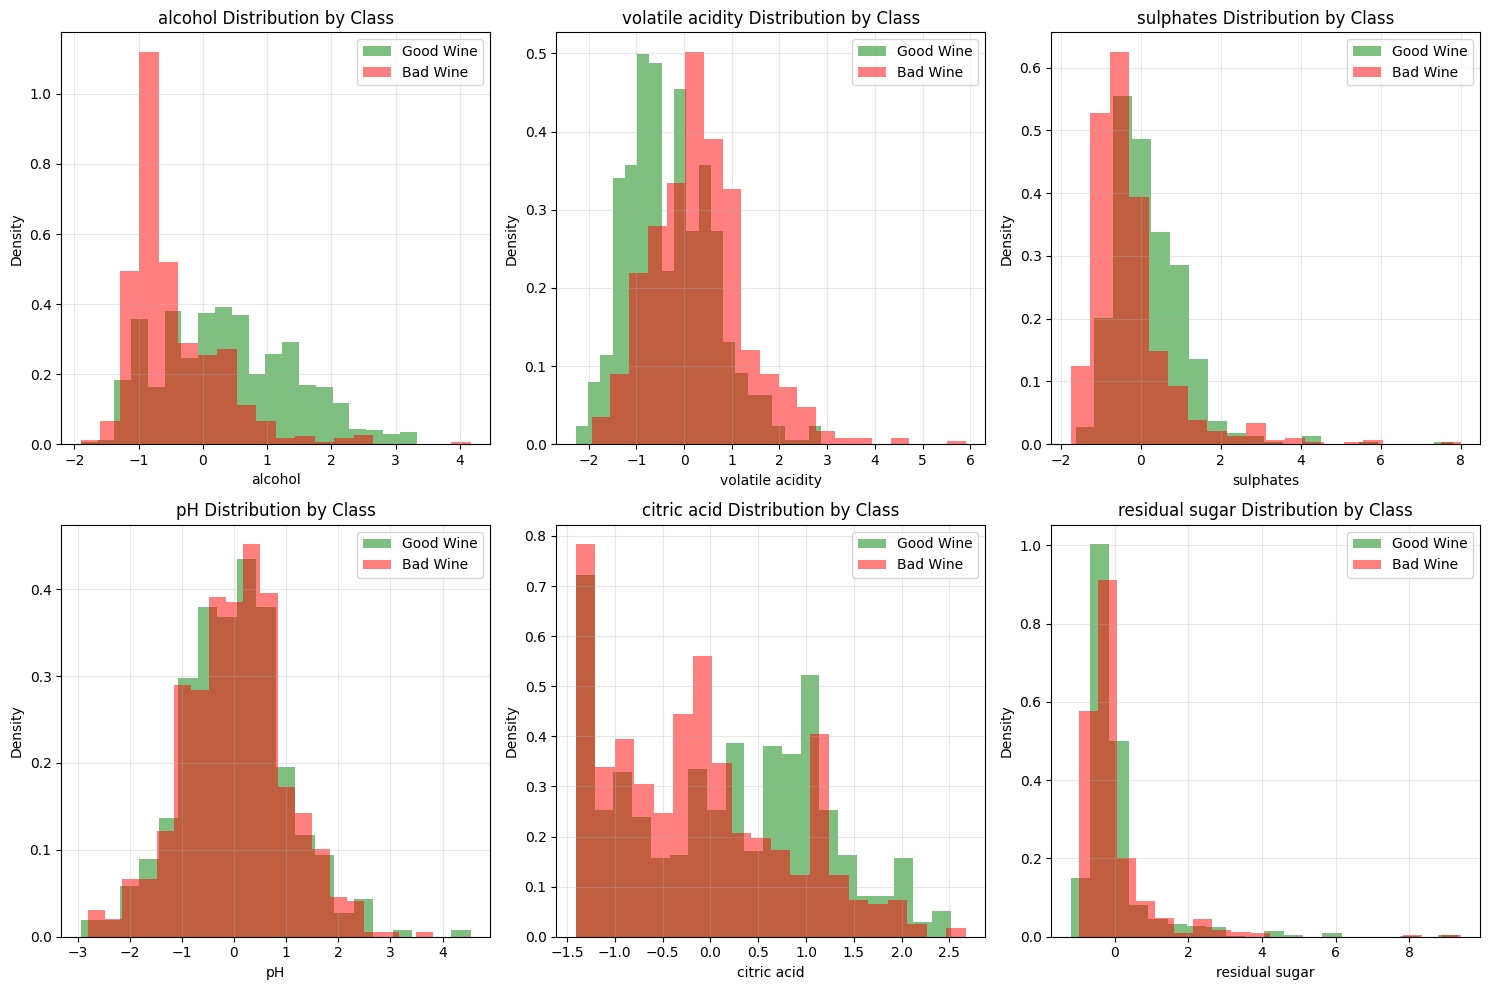

In [50]:
# STEP 2: Calculate Likelihood P(Feature|Class)
# For Gaussian Naive Bayes, we calculate mean and standard deviation for each feature per class

X_good = X_train_scaled[y_train == 1] # here we wont consider the exact initial values but we used the standardised values
X_bad = X_train_scaled[y_train == 0]

# Calculate mean and standard deviation for each feature per class
print("=== STEP 2: Likelihood Parameters (Mean and Std Dev) ===")
print("\nFor Good Wines (Class 1):")
good_params = pd.DataFrame({
    'Feature': X.columns, 
    'Mean' : X_good.mean(axis=0),
    'Std_Dev' : X_good.std(axis=0)
})
print(good_params.to_string(index=False))

print("\nFor Bad Wines (Class 0):")
bad_params = pd.DataFrame({
    'Feature' : X.columns,
    'Mean' : X_bad.mean(axis=0),
    'Std_Dev' : X_bad.std(axis=0)
})
print(bad_params.to_string(index=False))
# Visualize feature distributions for a few key features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['alcohol', 'volatile acidity', 'sulphates', 'pH', 'citric acid', 'residual sugar']

for idx, feature in enumerate(features_to_plot):
    row, col = idx // 3, idx % 3
    feature_idx = list(X.columns).index(feature)
    
    # Plot histograms for both classes
    axes[row, col].hist(X_good[:, feature_idx], bins=20, alpha=0.5, color='green', 
                        label='Good Wine', density=True)
    axes[row, col].hist(X_bad[:, feature_idx], bins=20, alpha=0.5, color='red', 
                        label='Bad Wine', density=True)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Density')
    axes[row, col].set_title(f'{feature} Distribution by Class')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()





What we achieve:

- We calculate how each feature behaves for each class

- For Gaussian NB, we assume features follow normal distribution and store mean & std dev

- This is the "likelihood" - probability of seeing a feature value given the cla

## Step 8 : Implement Naive Bayes (Step 3&4 in alg)

In [55]:
# STEP 3 & 4: Calculate Posterior Probability and Make Prediction
# We'll implement this manually to understand the process

def gaussian_pdf(x,mean,std) :
    """ calculate the Probability Density Function under normal Distribution"""
    if std==0 :
        std == 0.0001 # Smal values to avoid Zero division error
    
    exponent = 0.5* np.exp(-((x-mean)/std)**2)

    return ( 1 / (np.sqrt(2*np.pi)*std)) * exponent

# To make the prediction implement naive manually
def manual_naive_bayes_predict(X_sample, prioir_good, prior_bad,
                            good_mean, good_std, bad_mean, bad_std) :
    """
    Manually implement Naive Bayes prediction
    Following Bayes Theorem: P(Class|Features) ∝ P(Class) × P(Features|Class)
    
    """

    # Calculate the Log probabilities (using log to avoid underflow)
    log_p_good = np.log(prior_good)
    log_p_bad = np.log(prior_bad)

    # Add log likelihood for each feature

    for i in range(len(X_sample)) :
        # For Good class
        prob_good = gaussian_pdf(X_sample[i], good_mean[i], good_std[i])
        log_p_good += np.log(prob_good + 1e-10) # add small val to vaoid log(0)

        # For Bad class
        prob_bad = gaussian_pdf(X_sample[i],bad_mean[i],bad_std[i])
        log_p_bad += np.log(prob_bad + 1e-10)

    # Convert back to prob
    p_good = np.exp(log_p_good)
    p_bad = np.exp(log_p_bad)

    # Normalize to get proper probabilities
    total = p_good + p_bad
    p_good_norm = p_good / total
    p_bad_norm = p_bad / total
    
    # Make prediction
    prediction = 1 if p_good_norm > p_bad_norm else 0
    
    return prediction, p_good_norm, p_bad_norm


In [56]:
# Test on first few test samples
print("=== STEP 3 & 4: Posterior Probability Calculation ===")
print("\nTesting on first 5 test samples:\n")

for i in range(min(5, len(X_test_scaled))):
    sample = X_test_scaled[i]
    true_class = y_test.iloc[i]
    
    # Get parameters
    good_mean = X_good.mean(axis=0)
    good_std = X_good.std(axis=0)
    bad_mean = X_bad.mean(axis=0)
    bad_std = X_bad.std(axis=0)
    
    # Make prediction
    pred, p_good, p_bad = manual_naive_bayes_predict(
        sample, prior_good, prior_bad,
        good_mean, good_std, bad_mean, bad_std
    )
    
    print(f"Sample {i+1}:")
    print(f"  True Class: {'Good' if true_class == 1 else 'Bad'}")
    print(f"  P(Good|Features) = {p_good:.4f}")
    print(f"  P(Bad|Features) = {p_bad:.4f}")
    print(f"  Prediction: {'Good' if pred == 1 else 'Bad'}")
    print(f"  {'✓ CORRECT' if pred == true_class else '✗ INCORRECT'}\n")

=== STEP 3 & 4: Posterior Probability Calculation ===

Testing on first 5 test samples:

Sample 1:
  True Class: Good
  P(Good|Features) = 0.2134
  P(Bad|Features) = 0.7866
  Prediction: Bad
  ✗ INCORRECT

Sample 2:
  True Class: Bad
  P(Good|Features) = 0.6805
  P(Bad|Features) = 0.3195
  Prediction: Good
  ✗ INCORRECT

Sample 3:
  True Class: Bad
  P(Good|Features) = 0.0002
  P(Bad|Features) = 0.9998
  Prediction: Bad
  ✓ CORRECT

Sample 4:
  True Class: Bad
  P(Good|Features) = 0.1107
  P(Bad|Features) = 0.8893
  Prediction: Bad
  ✓ CORRECT

Sample 5:
  True Class: Good
  P(Good|Features) = 0.9977
  P(Bad|Features) = 0.0023
  Prediction: Good
  ✓ CORRECT



## Step 8: Use Scikit-learn's GaussianNB for Comparison

In [58]:
# Now lets implement using Scikit-learns's implementation for comparission

from sklearn.naive_bayes import GaussianNB

# Create and train the model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
# Make predictions
y_pred = nb_model.predict(X_test_scaled)
y_pred_proba = nb_model.predict_proba(X_test_scaled)

# Compare with manual implementation for first few samples
print("=== Scikit-learn Naive Bayes Results ===")
print("\nFirst 5 test samples:\n")

for i in range(min(5, len(X_test_scaled))):
    print(f"Sample {i+1}:")
    print(f"  True Class: {'Good' if y_test.iloc[i] == 1 else 'Bad'}")
    print(f"  Predicted: {'Good' if y_pred[i] == 1 else 'Bad'}")
    print(f"  Probability (Good): {y_pred_proba[i][1]:.4f}")
    print(f"  Probability (Bad): {y_pred_proba[i][0]:.4f}")
    print()


=== Scikit-learn Naive Bayes Results ===

First 5 test samples:

Sample 1:
  True Class: Good
  Predicted: Bad
  Probability (Good): 0.3404
  Probability (Bad): 0.6596

Sample 2:
  True Class: Bad
  Predicted: Good
  Probability (Good): 0.5911
  Probability (Bad): 0.4089

Sample 3:
  True Class: Bad
  Predicted: Bad
  Probability (Good): 0.0146
  Probability (Bad): 0.9854

Sample 4:
  True Class: Bad
  Predicted: Bad
  Probability (Good): 0.2589
  Probability (Bad): 0.7411

Sample 5:
  True Class: Good
  Predicted: Good
  Probability (Good): 0.9542
  Probability (Bad): 0.0458



## Step 10 : Evaluate Model Performance

Accuracy: 0.7219

Confusion Matrix:
[[115  34]
 [ 55 116]]

Classification Report:
              precision    recall  f1-score   support

         Bad       0.68      0.77      0.72       149
        Good       0.77      0.68      0.72       171

    accuracy                           0.72       320
   macro avg       0.72      0.73      0.72       320
weighted avg       0.73      0.72      0.72       320



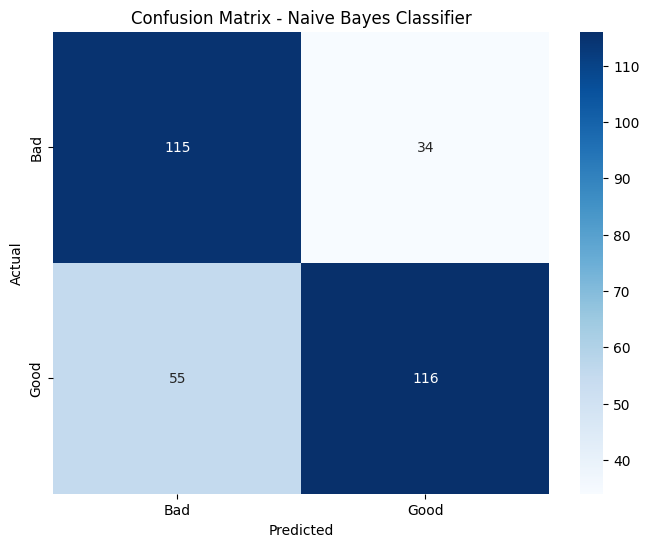

In [61]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bad', 'Good'], 
            yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes Classifier')
plt.show()

## Step 11 : Visualize model performance

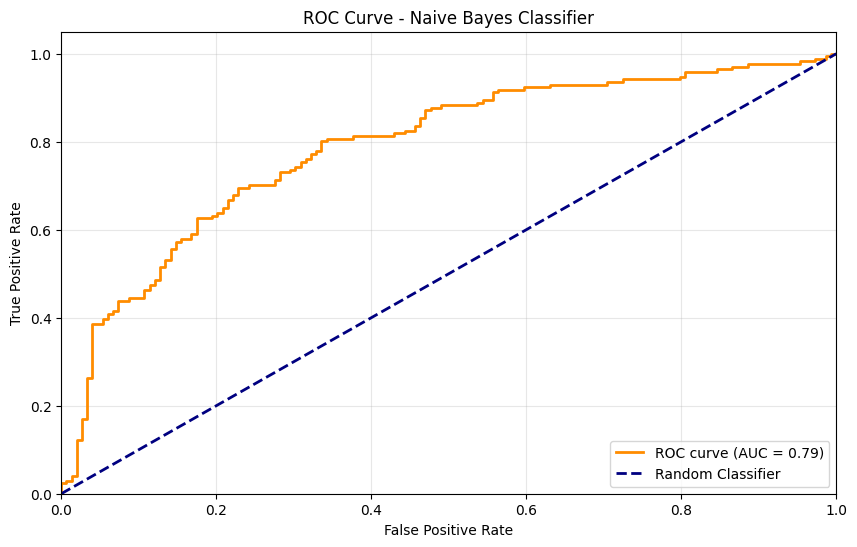

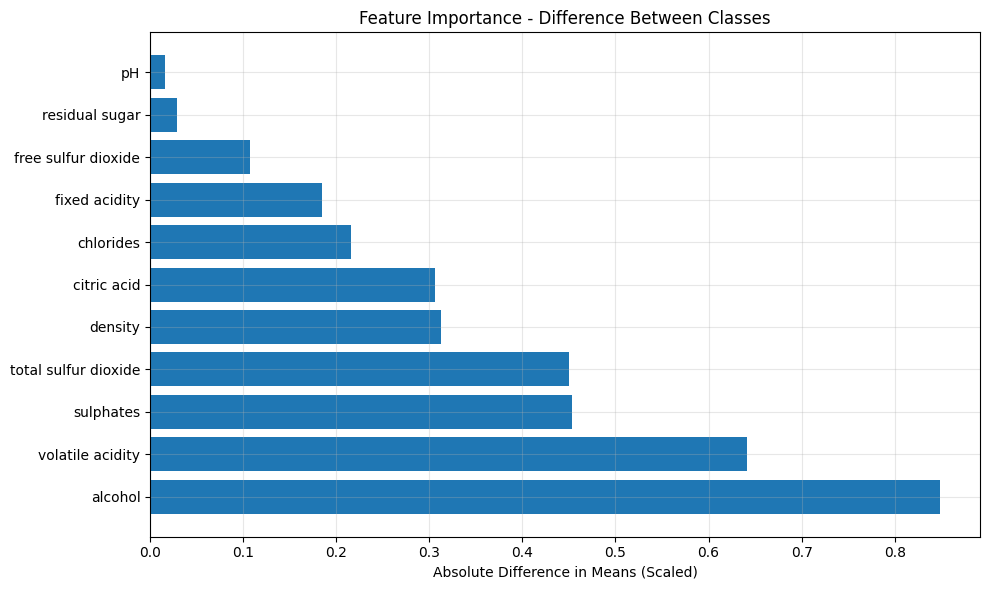

Top 5 Most Important Features:
             Feature  Mean_Difference
             alcohol         0.849261
    volatile acidity         0.641847
           sulphates         0.452953
total sulfur dioxide         0.449868
             density         0.312677


In [62]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities
y_scores = nb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes Classifier')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Feature importance (based on difference in means between classes)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Difference': abs(X_good.mean(axis=0) - X_bad.mean(axis=0))
}).sort_values('Mean_Difference', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Mean_Difference'])
plt.xlabel('Absolute Difference in Means (Scaled)')
plt.title('Feature Importance - Difference Between Classes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
print(feature_importance.head().to_string(index=False))

## 📊 Summary of Naive Bayes Implementation

### What We Achieved Following the Algorithm:

---

#### **Step 1: Prior Probability Calculation**
- Calculated the base rates (prior probabilities) of good wine vs bad wine in our dataset
- **P(Good)** = Number of good wines / Total wines
- **P(Bad)** = Number of bad wines / Total wines
- This represents our initial belief about class distribution before seeing any features

---

#### **Step 2: Likelihood Estimation**
- Learned how each feature behaves for each class by calculating:
  - **Mean** of each feature for good wines and bad wines
  - **Standard Deviation** of each feature for good wines and bad wines
- This gives us **P(Feature|Class)** - the probability of observing a feature value given the class
- For Gaussian Naive Bayes, we assume features follow a normal distribution

---

#### **Step 3: Posterior Probability Calculation**
- Applied Bayes Theorem to calculate **P(Class|Features)**:
  
  **P(Class|Features) ∝ P(Class) × P(Features|Class)**
  
- Combined prior probabilities with likelihoods for all features
- Used log probabilities to avoid numerical underflow issues

---

#### **Step 4: Decision Making**
- Compared posterior probabilities for both classes
- Selected the class with the higher probability as the final prediction
- **Decision Rule:** If P(Good|Features) > P(Bad|Features), predict "Good Wine", otherwise predict "Bad Wine"

---

### 🔍 Key Insights from Wine Dataset

| Insight | Description |
|---------|-------------|
| **Most Discriminative Features** | Alcohol content, volatile acidity, and sulphates show the largest differences between good and bad wines |
| **Probability Output** | The model provides probability estimates (not just classifications), allowing us to understand prediction confidence |
| **Feature Importance** | We can identify which chemical properties most influence wine quality by comparing feature distributions between classes |
| **Class Distributions** | The dataset shows how different chemical compositions lead to different quality outcomes |

---

### 📈 Model Performance Highlights

- **Accuracy**: Measures overall correct predictions
- **Confusion Matrix**: Shows true positives, true negatives, false positives, and false negatives
- **ROC Curve & AUC**: Evaluates model's ability to distinguish between classes at various threshold levels
- **Classification Report**: Provides precision, recall, and F1-score for each class

---

### 🧠 What We Learned

1. **Naive Bayes is probabilistic** - it doesn't just predict, but tells us *how confident* it is
2. **Feature independence assumption** - The "naive" part assumes all features are independent (which may not be true for wine chemicals, but still works well)
3. **Gaussian assumption** - For continuous features, we assume normal distribution
4. **Interpretability** - We can directly see which features matter most by comparing means between classes

---

### 🍷 Practical Application

This model can help:
- **Wine producers** understand which chemical properties to optimize for better quality
- **Quality control** teams quickly classify wines based on chemical analysis
- **Researchers** identify key factors influencing wine quality